# Computer Vision: Object Detection & Segmentation
Hands-on exploration of object detection and segmentation using real CV libraries and pretrained models.

**Prerequisites:**
```bash
pip install torch torchvision opencv-python-headless Pillow matplotlib numpy
```

📺 **Video Lecture:** [https://youtu.be/gMu8VeBheUc](https://youtu.be/gMu8VeBheUc)

## Cell 1: Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.ops import nms as tv_nms
from PIL import Image, ImageDraw, ImageFilter
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print(f"PyTorch version: {torch.__version__}")
print(f"OpenCV version: {cv2.__version__}")

PyTorch version: 2.11.0
OpenCV version: 4.13.0


## Section 1: Image Fundamentals with OpenCV/PIL

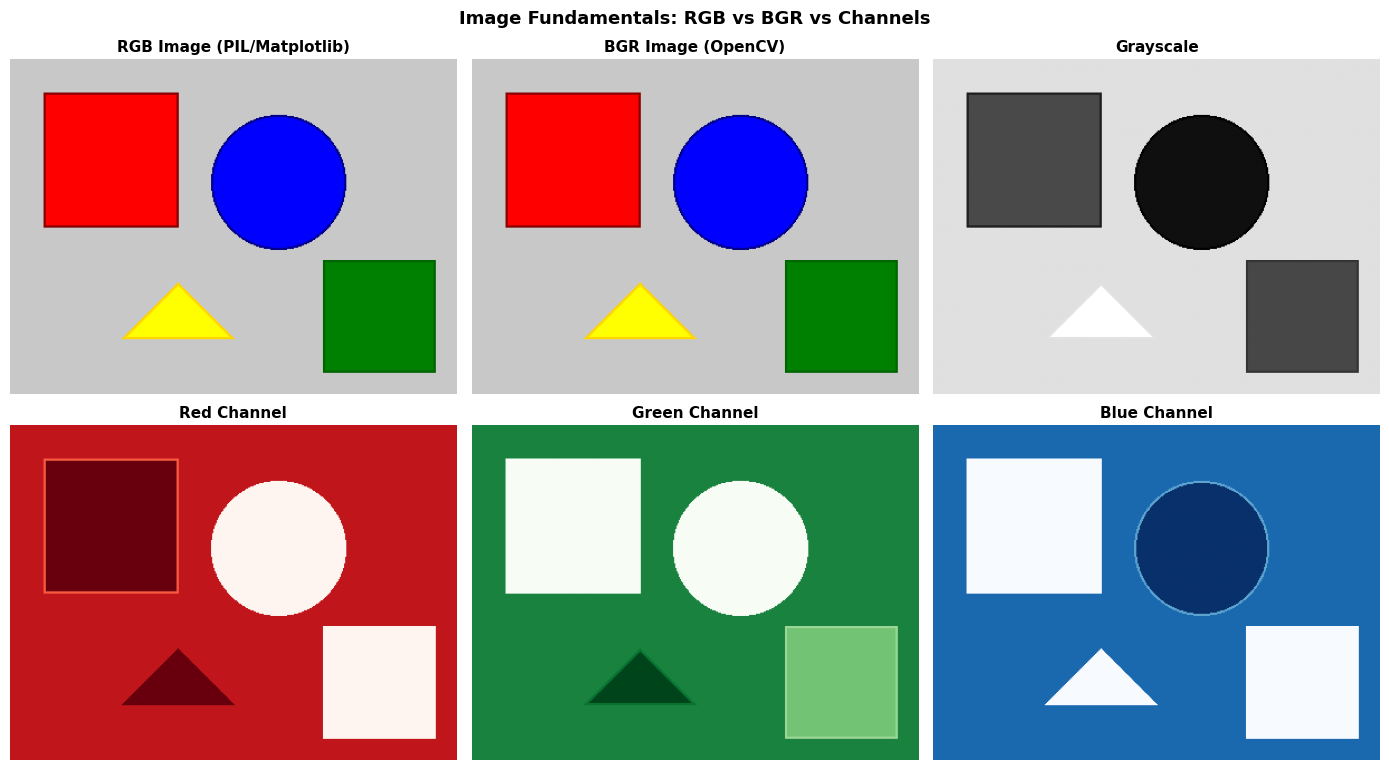

Image shape (H×W×C): (300, 400, 3)
OpenCV quirk: OpenCV uses BGR by default, not RGB!


In [3]:
# Create a synthetic image with PIL (colored rectangles + circles)
img = Image.new('RGB', (400, 300), color=(200, 200, 200))
draw = ImageDraw.Draw(img)

# Draw colored shapes
draw.rectangle([30, 30, 150, 150], fill='red', outline='darkred', width=2)
draw.ellipse([180, 50, 300, 170], fill='blue', outline='darkblue', width=2)
draw.rectangle([280, 180, 380, 280], fill='green', outline='darkgreen', width=2)
draw.polygon([(100, 250), (150, 200), (200, 250)], fill='yellow', outline='gold', width=2)

# Convert PIL to numpy for display
img_rgb = np.array(img)

# Convert RGB to BGR for OpenCV
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

# Show RGB vs BGR
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# RGB display
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('RGB Image (PIL/Matplotlib)', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# BGR display (channels reversed)
axes[0, 1].imshow(img_bgr[:, :, ::-1])  # Flip to see BGR effect
axes[0, 1].set_title('BGR Image (OpenCV)', fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

# Grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
axes[0, 2].imshow(img_gray, cmap='gray')
axes[0, 2].set_title('Grayscale', fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

# Channel splitting with cv2.split()
b, g, r = cv2.split(img_bgr)

axes[1, 0].imshow(r, cmap='Reds')
axes[1, 0].set_title('Red Channel', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(g, cmap='Greens')
axes[1, 1].set_title('Green Channel', fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(b, cmap='Blues')
axes[1, 2].set_title('Blue Channel', fontsize=11, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Image Fundamentals: RGB vs BGR vs Channels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Image shape (H×W×C): {img_rgb.shape}")
print(f"OpenCV quirk: OpenCV uses BGR by default, not RGB!")

## Section 2: Convolution with OpenCV (Edge Detection)

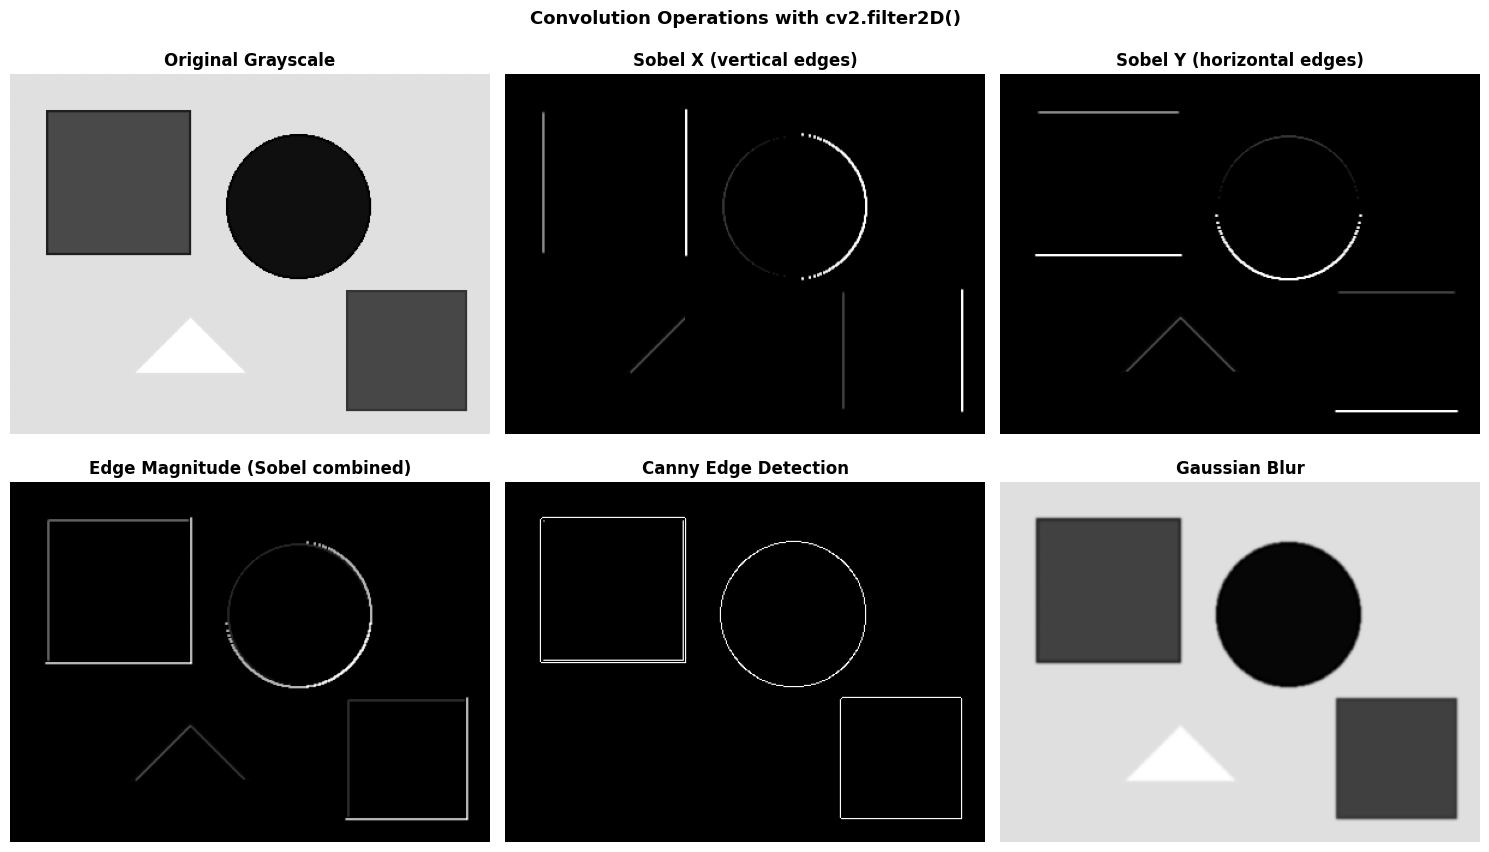

Much cleaner than hand-coded numpy convolution!
Sobel magnitude range: [0.0, 360.6]
Canny edges detected: 1514 pixels


In [4]:
# Use cv2.filter2D() with various kernels for cleaner edge detection

# Sobel kernels for edge detection
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

# Gaussian kernel for smoothing
gaussian = cv2.getGaussianKernel(5, 1.0)
gaussian = gaussian @ gaussian.T  # Make 2D

# Laplacian kernel for second-order edge detection
laplacian = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)

# Apply filters using cv2.filter2D()
edges_x = cv2.filter2D(img_gray, -1, sobel_x)
edges_y = cv2.filter2D(img_gray, -1, sobel_y)
edges_magnitude = np.sqrt(edges_x.astype(np.float32)**2 + edges_y.astype(np.float32)**2)

# Canny edge detection (production-grade)
edges_canny = cv2.Canny(img_gray, 100, 200)

# Laplacian
edges_laplacian = cv2.filter2D(img_gray, -1, laplacian)

# Gaussian blur
img_blurred = cv2.GaussianBlur(img_gray, (5, 5), 1.0)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(edges_x), cmap='gray')
axes[0, 1].set_title('Sobel X (vertical edges)', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(np.abs(edges_y), cmap='gray')
axes[0, 2].set_title('Sobel Y (horizontal edges)', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(edges_magnitude, cmap='gray')
axes[1, 0].set_title('Edge Magnitude (Sobel combined)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_canny, cmap='gray')
axes[1, 1].set_title('Canny Edge Detection', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_blurred, cmap='gray')
axes[1, 2].set_title('Gaussian Blur', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Convolution Operations with cv2.filter2D()', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Much cleaner than hand-coded numpy convolution!")
print(f"Sobel magnitude range: [{edges_magnitude.min():.1f}, {edges_magnitude.max():.1f}]")
print(f"Canny edges detected: {edges_canny.sum() // 255} pixels")

## Section 3: IoU Computation

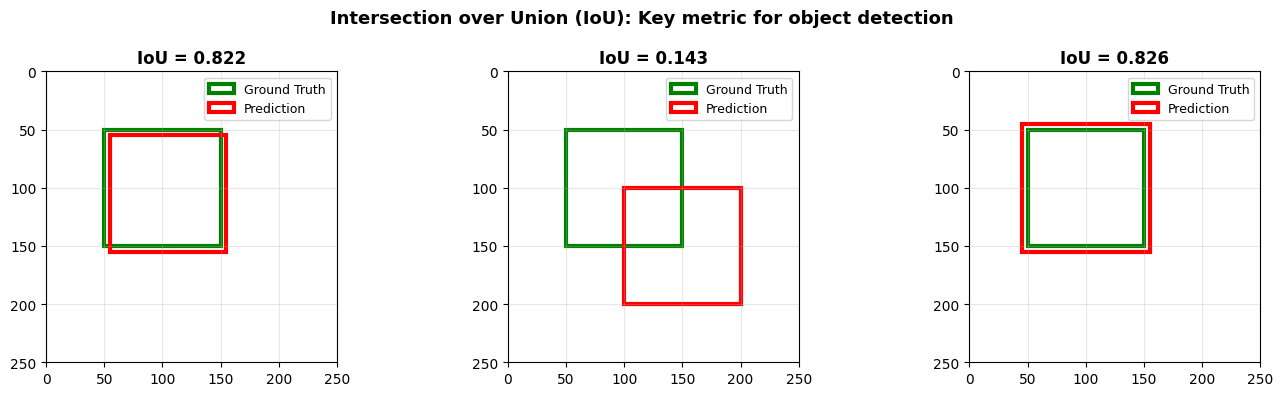

IoU > 0.5 is typically the threshold for a 'correct' detection (AP metric).


In [5]:
def compute_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two boxes.
    Boxes format: [x1, y1, x2, y2]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    # Intersection area
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Union area
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

# Visualize IoU with different overlap scenarios
gt_box = [50, 50, 150, 150]  # Ground truth box
pred_boxes = [
    [55, 55, 155, 155],      # High overlap (good)
    [100, 100, 200, 200],    # Medium overlap (okay)
    [45, 45, 155, 155],      # Almost perfect (excellent)
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, pred_box in zip(axes, pred_boxes):
    iou = compute_iou(gt_box, pred_box)
    
    # Draw ground truth (green)
    rect_gt = patches.Rectangle((gt_box[0], gt_box[1]),
                                  gt_box[2] - gt_box[0],
                                  gt_box[3] - gt_box[1],
                                  fill=False, edgecolor='green',
                                  linewidth=3, label='Ground Truth')
    ax.add_patch(rect_gt)
    
    # Draw prediction (red)
    rect_pred = patches.Rectangle((pred_box[0], pred_box[1]),
                                    pred_box[2] - pred_box[0],
                                    pred_box[3] - pred_box[1],
                                    fill=False, edgecolor='red',
                                    linewidth=3, label='Prediction')
    ax.add_patch(rect_pred)
    
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 250)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(f'IoU = {iou:.3f}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Intersection over Union (IoU): Key metric for object detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"IoU > 0.5 is typically the threshold for a 'correct' detection (AP metric).")

## Section 4: Non-Maximum Suppression (NMS)

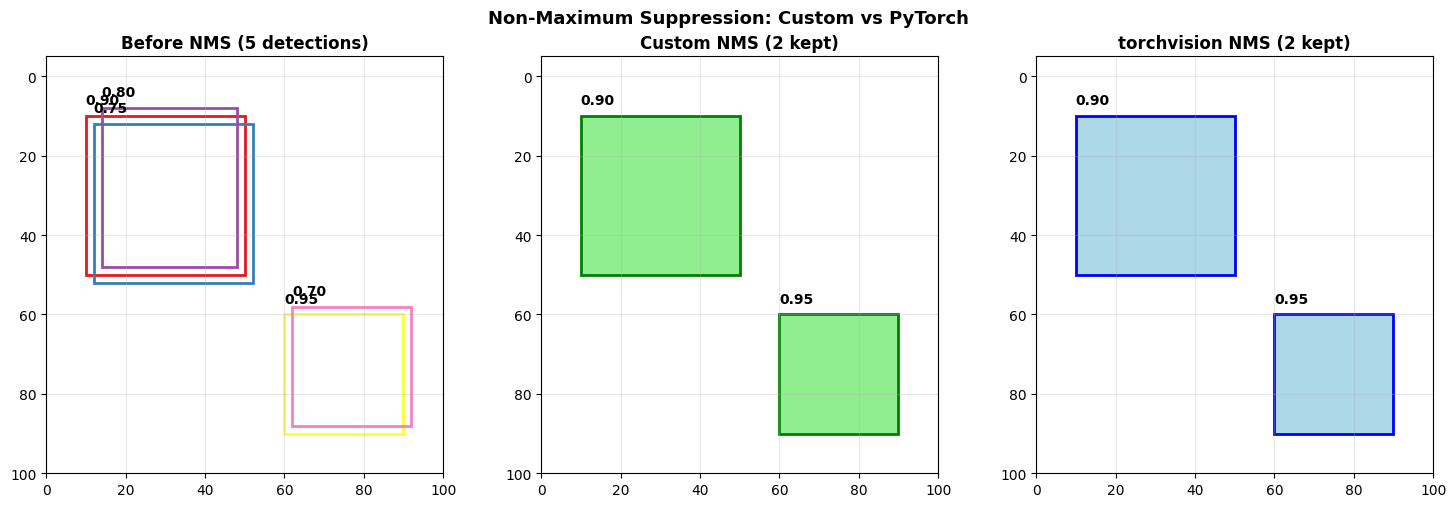

Custom NMS kept indices: [np.int64(3), np.int64(0)]
PyTorch NMS kept indices: [3, 0]
Both approaches agree: True


In [6]:
def nms_custom(boxes, scores, iou_threshold=0.5):
    """
    Custom implementation of Non-Maximum Suppression.
    Removes overlapping detections, keeping only the best ones.
    """
    if len(boxes) == 0:
        return []
    
    # Sort by scores (descending)
    indices = np.argsort(scores)[::-1]
    keep = []
    
    while len(indices) > 0:
        current = indices[0]
        keep.append(current)
        
        if len(indices) == 1:
            break
        
        # Compute IoU between current box and all remaining boxes
        ious = np.array([compute_iou(boxes[current], boxes[i]) for i in indices[1:]])
        
        # Keep only boxes with IoU below threshold
        indices = indices[1:][ious < iou_threshold]
    
    return keep

# Create synthetic detections with overlapping boxes
boxes = np.array([
    [10, 10, 50, 50],   # Region 1 cluster
    [12, 12, 52, 52],
    [14, 8, 48, 48],
    [60, 60, 90, 90],   # Region 2 cluster
    [62, 58, 92, 88],
], dtype=np.float32)

scores = np.array([0.9, 0.75, 0.8, 0.95, 0.7])

# Custom NMS
kept_custom = nms_custom(boxes, scores, iou_threshold=0.5)

# PyTorch NMS (production approach)
boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
scores_tensor = torch.tensor(scores, dtype=torch.float32)
kept_torchvision = tv_nms(boxes_tensor, scores_tensor, iou_threshold=0.5).tolist()

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Before NMS
ax = axes[0]
for i, (box, score) in enumerate(zip(boxes, scores)):
    rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                               fill=False, edgecolor=plt.cm.Set1(i / len(boxes)),
                               linewidth=2)
    ax.add_patch(rect)
    ax.text(box[0], box[1] - 3, f'{score:.2f}', fontsize=10, fontweight='bold')

ax.set_xlim(0, 100)
ax.set_ylim(-5, 100)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title(f'Before NMS ({len(boxes)} detections)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

# After Custom NMS
ax = axes[1]
for i in kept_custom:
    box, score = boxes[i], scores[i]
    rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                               fill=True, facecolor='lightgreen', edgecolor='green',
                               linewidth=2)
    ax.add_patch(rect)
    ax.text(box[0], box[1] - 3, f'{score:.2f}', fontsize=10, fontweight='bold')

ax.set_xlim(0, 100)
ax.set_ylim(-5, 100)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title(f'Custom NMS ({len(kept_custom)} kept)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

# After PyTorch NMS
ax = axes[2]
for i in kept_torchvision:
    box, score = boxes[i], scores[i]
    rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                               fill=True, facecolor='lightblue', edgecolor='blue',
                               linewidth=2)
    ax.add_patch(rect)
    ax.text(box[0], box[1] - 3, f'{score:.2f}', fontsize=10, fontweight='bold')

ax.set_xlim(0, 100)
ax.set_ylim(-5, 100)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title(f'torchvision NMS ({len(kept_torchvision)} kept)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

plt.suptitle('Non-Maximum Suppression: Custom vs PyTorch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Custom NMS kept indices: {kept_custom}")
print(f"PyTorch NMS kept indices: {kept_torchvision}")
print(f"Both approaches agree: {set(kept_custom) == set(kept_torchvision)}")

## Section 5: Pretrained Object Detection with Faster R-CNN

Loading pretrained Faster R-CNN (MobileNet V3 + FPN)...
Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /Users/sanigam/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:02<00:00, 34.1MB/s]


Model loaded and set to eval mode.
Running inference...


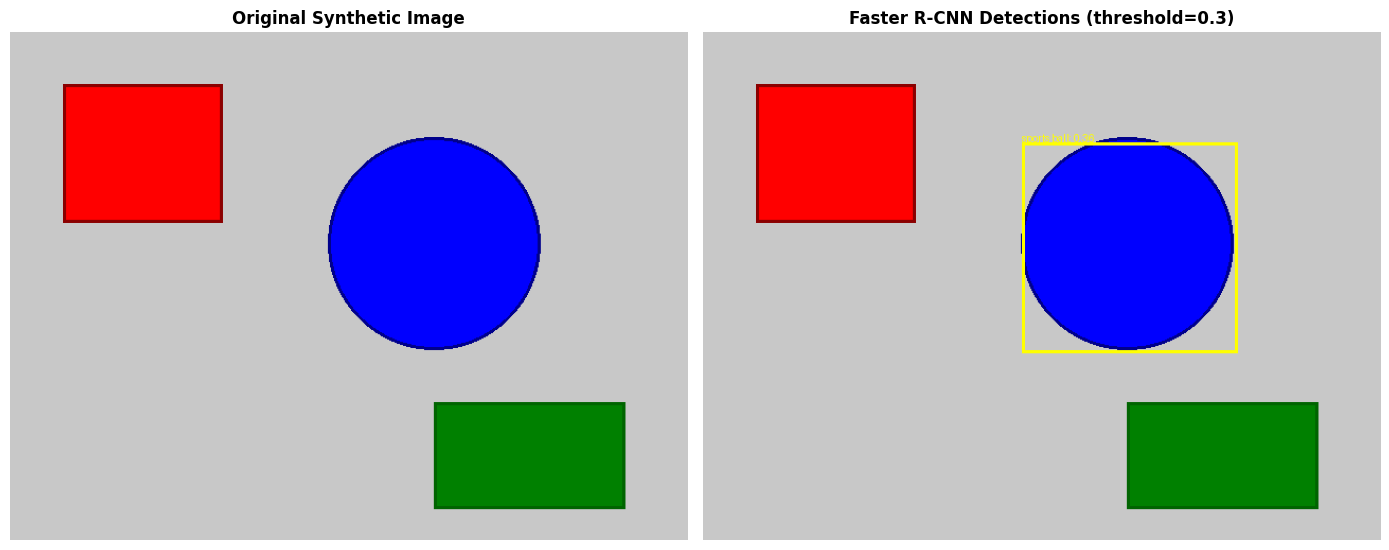


Detection Results:
  Total detected: 2 objects
  Above threshold (0.3): 1 objects

Note: Synthetic colored shapes may not produce meaningful detections
      because Faster R-CNN is trained on COCO (real-world objects).
      This demo shows the model API and inference pipeline.


In [7]:
# Load pretrained Faster R-CNN with MobileNet backbone (small & fast)
print("Loading pretrained Faster R-CNN (MobileNet V3 + FPN)...")
weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
model.eval()
print("Model loaded and set to eval mode.")

# Create a synthetic scene with shapes
img_detection = Image.new('RGB', (640, 480), color=(200, 200, 200))
draw = ImageDraw.Draw(img_detection)

# Draw shapes
draw.rectangle([50, 50, 200, 180], fill='red', outline='darkred', width=3)
draw.ellipse([300, 100, 500, 300], fill='blue', outline='darkblue', width=3)
draw.rectangle([400, 350, 580, 450], fill='green', outline='darkgreen', width=3)

# Prepare image for model
preprocess = weights.transforms()
batch = preprocess(img_detection).unsqueeze(0)

# Run inference
print("Running inference...")
with torch.no_grad():
    predictions = model(batch)[0]

# Display predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original image
axes[0].imshow(img_detection)
axes[0].set_title('Original Synthetic Image', fontweight='bold', fontsize=12)
axes[0].axis('off')

# Detected image
img_detected = img_detection.copy()
draw_detected = ImageDraw.Draw(img_detected)

detection_count = 0
for i in range(len(predictions['boxes'])):
    score = predictions['scores'][i].item()
    
    # Only show detections above threshold
    if score > 0.3:
        box = predictions['boxes'][i].numpy()
        label_id = predictions['labels'][i].item()
        category_name = weights.meta['categories'][label_id]
        
        # Draw bounding box
        draw_detected.rectangle(
            [box[0], box[1], box[2], box[3]],
            outline='yellow',
            width=3
        )
        
        # Draw label
        label_text = f"{category_name}: {score:.2f}"
        draw_detected.text((int(box[0]), int(box[1]) - 10), label_text,
                           fill='yellow', font=None)
        
        detection_count += 1

axes[1].imshow(img_detected)
axes[1].set_title(f'Faster R-CNN Detections (threshold=0.3)', fontweight='bold', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nDetection Results:")
print(f"  Total detected: {len(predictions['boxes'])} objects")
print(f"  Above threshold (0.3): {detection_count} objects")
print(f"\nNote: Synthetic colored shapes may not produce meaningful detections")
print(f"      because Faster R-CNN is trained on COCO (real-world objects).")
print(f"      This demo shows the model API and inference pipeline.")

## Section 6: Image Segmentation with OpenCV

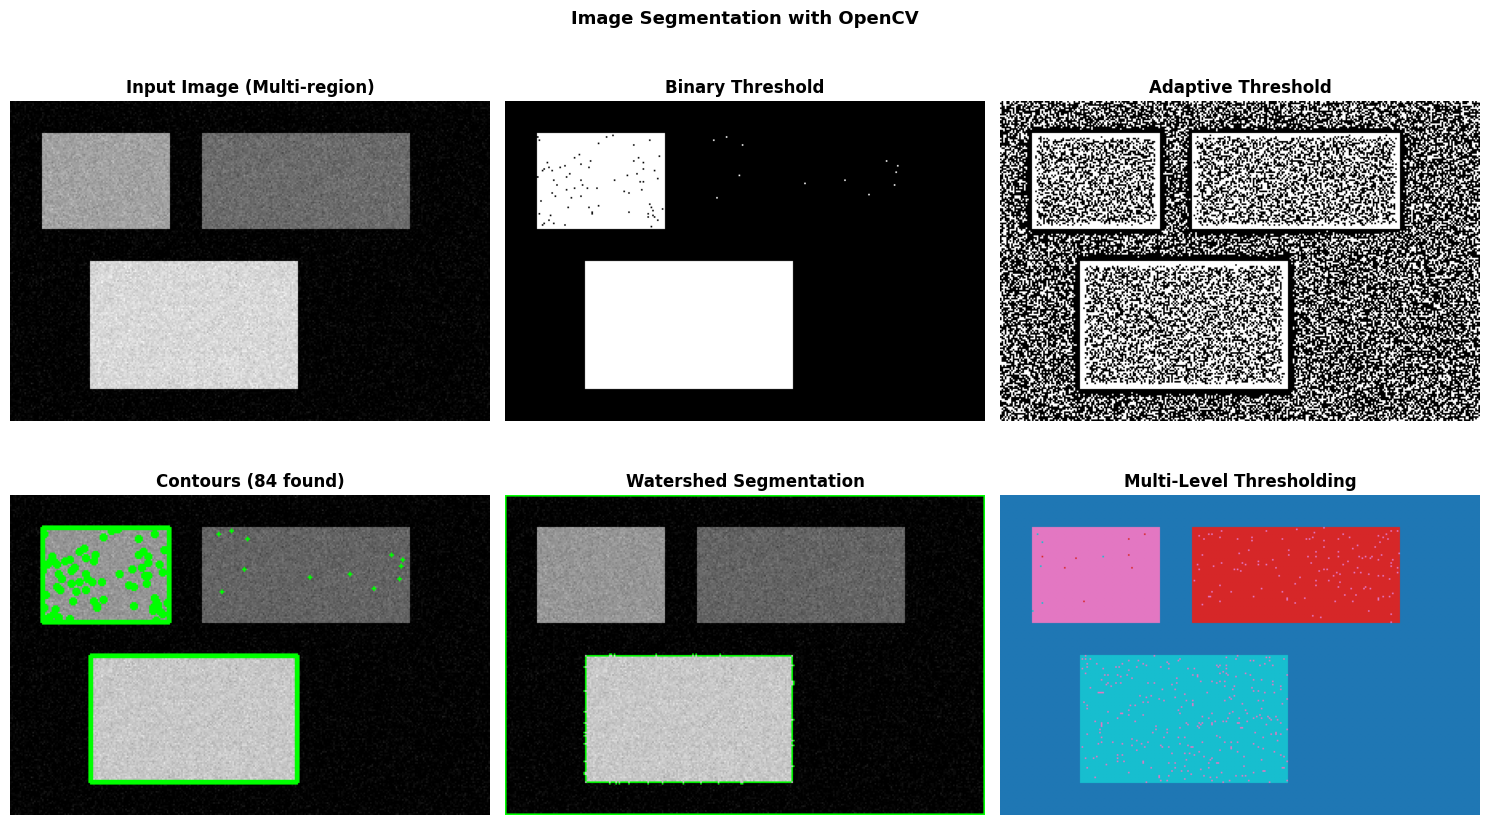

Segmentation Results:
  Contours detected: 84
  Largest contour area: 10191.0
  Unique segments (watershed): 3


In [8]:
# Create a synthetic multi-region image
seg_img = np.zeros((200, 300), dtype=np.uint8)
seg_img[20:80, 20:100] = 150      # Region 1
seg_img[20:80, 120:250] = 100     # Region 2
seg_img[100:180, 50:180] = 200    # Region 3

# Add some noise
noise = np.random.normal(0, 10, seg_img.shape).astype(np.float32)
seg_img = np.clip(seg_img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

# 1. Binary thresholding
_, binary = cv2.threshold(seg_img, 127, 255, cv2.THRESH_BINARY)

# 2. Adaptive thresholding (better for varying lighting)
adaptive = cv2.adaptiveThreshold(seg_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

# 3. Contour detection
contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

img_contours = np.stack([seg_img] * 3, axis=2)  # Convert to RGB for drawing
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# 4. Watershed segmentation (advanced)
img_watershed = seg_img.copy()
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
sure_bg = cv2.dilate(binary, kernel, iterations=3)
dist = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
_, sure_fg = cv2.threshold(dist, 0.7 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
img_ws_color = np.stack([seg_img] * 3, axis=2)
cv2.watershed(img_ws_color, markers)
img_ws_color[markers == -1] = [0, 255, 0]  # Mark boundaries in green

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(seg_img, cmap='gray')
axes[0, 0].set_title('Input Image (Multi-region)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary, cmap='gray')
axes[0, 1].set_title('Binary Threshold', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(adaptive, cmap='gray')
axes[0, 2].set_title('Adaptive Threshold', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(img_contours, cmap='gray')
axes[1, 0].set_title(f'Contours ({len(contours)} found)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_ws_color)
axes[1, 1].set_title('Watershed Segmentation', fontweight='bold')
axes[1, 1].axis('off')

# Multi-threshold segmentation
multi_seg = np.zeros_like(seg_img)
multi_seg[seg_img > 180] = 3
multi_seg[(seg_img > 120) & (seg_img <= 180)] = 2
multi_seg[(seg_img > 50) & (seg_img <= 120)] = 1

axes[1, 2].imshow(multi_seg, cmap='tab10')
axes[1, 2].set_title('Multi-Level Thresholding', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Image Segmentation with OpenCV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Segmentation Results:")
print(f"  Contours detected: {len(contours)}")
print(f"  Largest contour area: {max(cv2.contourArea(c) for c in contours) if contours else 0:.1f}")
print(f"  Unique segments (watershed): {len(np.unique(markers))}")

## Section 7: Data Augmentation with torchvision.transforms

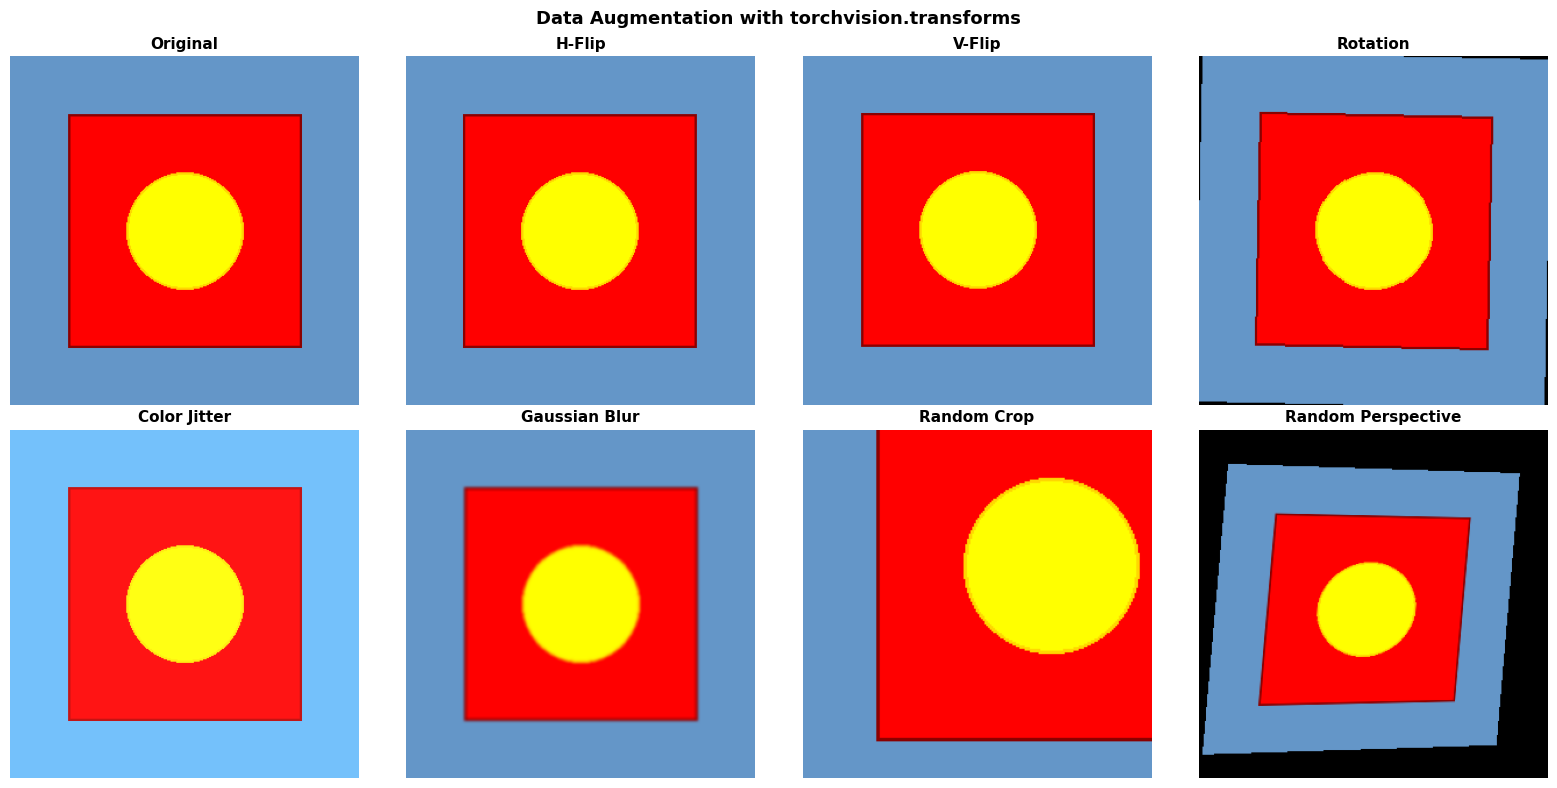

Data augmentation is crucial for:
  - Increasing dataset diversity
  - Reducing overfitting
  - Improving model robustness

Common augmentations: flip, rotate, crop, color jitter, blur, perspective distortion


In [9]:
# Define various augmentations using torchvision.transforms
transform_dict = {
    'Original': transforms.Compose([]),
    'H-Flip': transforms.RandomHorizontalFlip(p=1.0),
    'V-Flip': transforms.RandomVerticalFlip(p=1.0),
    'Rotation': transforms.RandomRotation(degrees=45),
    'Color Jitter': transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                            saturation=0.3, hue=0.1),
    'Gaussian Blur': transforms.GaussianBlur(kernel_size=5, sigma=(0.5, 2.0)),
    'Random Crop': transforms.RandomCrop(size=(200, 200), pad_if_needed=True),
    'Random Perspective': transforms.RandomPerspective(distortion_scale=0.3, p=1.0),
}

# Create base image as PIL
aug_img = Image.new('RGB', (300, 300), color=(100, 150, 200))
draw = ImageDraw.Draw(aug_img)
draw.rectangle([50, 50, 250, 250], fill='red', outline='darkred', width=2)
draw.ellipse([100, 100, 200, 200], fill='yellow', outline='gold', width=2)

# Apply augmentations
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (title, transform) in enumerate(transform_dict.items()):
    augmented = transform(aug_img)
    axes[idx].imshow(augmented)
    axes[idx].set_title(title, fontweight='bold', fontsize=11)
    axes[idx].axis('off')

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle('Data Augmentation with torchvision.transforms', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Data augmentation is crucial for:")
print("  - Increasing dataset diversity")
print("  - Reducing overfitting")
print("  - Improving model robustness")
print("\nCommon augmentations: flip, rotate, crop, color jitter, blur, perspective distortion")

## Section 8: Interview Takeaways

### Key Concepts

**Object Detection:**
- Localizes AND classifies objects in an image
- Returns bounding boxes + class labels + confidence scores
- Popular architectures: YOLO, Faster R-CNN, SSD, DETR

**Intersection over Union (IoU):**
- Measures overlap between predicted and ground truth boxes
- Formula: `IoU = Intersection / Union`
- Threshold of 0.5 is standard for evaluating detections

**Non-Maximum Suppression (NMS):**
- Removes redundant overlapping detections
- Keeps high-confidence boxes, suppresses nearby lower-confidence ones
- Critical post-processing step in object detection pipelines

**Image Segmentation:**
- **Semantic segmentation**: assigns a class label to each pixel (no instance distinction)
- **Instance segmentation**: separates individual objects (e.g., Mask R-CNN)
- **Panoptic segmentation**: combines semantic + instance segmentation

**Convolution Operations:**
- Foundation of modern CNNs
- Sobel, Laplacian, Gaussian kernels detect edges and smooth images
- OpenCV's `cv2.filter2D()` is production-grade

**Data Augmentation:**
- Flip (horizontal/vertical), rotate, crop, color jitter, blur, perspective distortion
- Essential for reducing overfitting and improving generalization
- torchvision.transforms provides efficient, composable augmentations

**Transfer Learning:**
- Leveraging pretrained models (ImageNet, COCO) as backbones
- Fine-tuning on task-specific data is standard practice
- Faster and better than training from scratch

### Modern Architectures
- **YOLO**: Real-time, single-shot detection
- **Faster R-CNN**: Two-stage detector, high accuracy
- **DETR**: Transformer-based object detection
- **Mask R-CNN**: Instance segmentation (adds mask branch to Faster R-CNN)
- **SAM (Segment Anything)**: Zero-shot segmentation with prompts

### Libraries & Tools
- **PyTorch + torchvision**: Modern deep learning framework with pretrained models
- **OpenCV (cv2)**: Classical computer vision operations (filters, contours, etc.)
- **PIL/Pillow**: Image manipulation and creation
- **NumPy**: Numerical operations and array manipulation

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>